# COVER TIME OF SIMPLE RANDOM WALKS ON A GRAPH

# PROJECT

## What is a random walk

A random walk on a graph is a mathematical process where a "walker" moves from their current node to a randomly chosen neighboring node, repeating this step continuously. In my case we are treating the complete graph. The complete graph is a graph in which every pair of distinct vertices is connected by a unique edge.

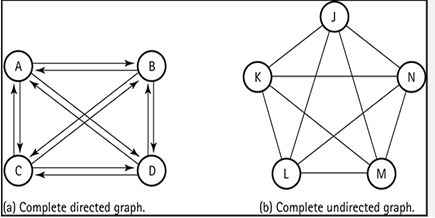


When starting from a vertex  the next one is one of the other vertices that choose with a uniform probability. 

## COVER TIME

The cover time is the time needed for the random walk to visit every single vertex at least once. It is the expected (average) number of steps to visit all nodes. The cover time is always taken as the worst-case starting vertex which means the one that makes covering hardest. But the in the complete graph case it doesnt matter where to start because on a complete graph every vertex looks exactly the same — same degree, same neighbors, same structure. So all starting vertices give the identical expected cover time. 
$$
T_{\mathrm{cov}}(G) = max (\mathbb{E}(T_v)) = \mathbb{E}(T_v) 
$$


# Project

We want to show that if we think of $\kappa$ as a function of the graph size and choose it correctly, then $\kappa$ random walks can cover a complete graph $\kappa$ times faster than a single random walk.

Consider a *complete graph* $G$ on $n$ vertices. By running several simulations and collecting the results in appropriate plots, show that:

- The cover time $T_{\mathrm{cov}}(G)$ grows as $c n \log n$, for some constant $c > 0$.

- If $\kappa = \kappa(n) = n$, the $\kappa$-cover time $T_{\mathrm{cov}}^{\kappa}(G)$ grows as $c \log n$, for some constant $c > 0$.

Perform the analysis for graph sizes of the form

$$
n = 500 \alpha, \quad \text{with } \alpha \in \{1,2,\dots,20\}
$$

(integer numbers from 1 to 20).

---

**Remark.** Notice that, if $G$ is the complete graph, then

$$
T_{\mathrm{cov}}(G) = \mathbb{E}(T_v)
\quad \text{and} \quad
T_{\mathrm{cov}}^{\kappa}(G) = \mathbb{E}(T_v^{\kappa}),
$$

as the collections $(T_v)_{v \in V}$ and $(T_v^{\kappa})_{v \in V}$ are families of i.i.d. random variables.

# PROJECT CODE

In [2]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import math

### move to the next node without picking the current node

Since we have a complete graph, it doesnt matter  from which vertex we start. Each vertices are symmetric. In a complete graph we can move uniformly from a node i to another.


Probability of moving from i to j:
$$
P(i \to j) = \frac{1}{n - 1}, \quad (j \ne i)
$$

In the following  function what we are doing is {0,...,n-1}\{current}:
starting from 0 to n-1 we have n exact nodes
we remove a value from the n nodes. If current_node=2 and n=5 : {0,1,2,3,4} it becomes n=4 : {0, 1, 2, 3}. 

rng.integers(0, n-1) can only give you consecutive numbers — it has no way to produce the "gap" set {0,1,3,4} directly. It will always output {0,1,2,3}.

but we cannot go to 2 from 2, so we have to remove it. and to do this we use: return j if j< current else j+1. If the node  is smaller then current it remains the same, if grater it will be +1. 


In [4]:
def next_vertex(current, n, rng):
    j = rng.integers(0, n - 1)          # draw from {0, 1, ..., n-2}
    return j if j < current else j + 1  # shift to skip current vertex
 

# Single walker cover time

Run **one random walk** on (K_n) starting at `start` and return **how many steps** it took until **all n nodes have been visited at least once** (=cover time for that run).

In [5]:
def single_walk_cover_time(n, rng):
    current = 0         # starting vertex — doesn't matter which one
    visited = {current} # vertex 0 is visited from the start, we use a set because we want to have each vertex just once (python sets doesn't have duplicates)
                        # python set gives us also the length of the  set so we'll know how many vertices we collected, and when len=n the loop stops
    steps = 0
 
    while len(visited) < n:
        current = next_vertex(current, n, rng)
        visited.add(current)
        steps += 1
 
    return steps
 

### Estimate the cover time T_cov by averaging M simulations -> Monte Carlo

The estimate_single_cover_time runs the single walk M times independently and returns the average -> the Monte Carlo estimate of $ (\mathbb{E}(T_v)) $.


Each simulation gives one random value of $T_v$. By averaging M of them:

$$E[T_v] \approx \frac{1}{M}\sum_{j=1}^{M} T_v[j]$$

The more simulations, the closer the average gets to the true expectation.

In [6]:
def estimate_single_cover_time(n, M=300, rng=None): # n=nr of vertices(graph size), rng=is a controlled random number generator.
                                                    # The seed fixes its output so the results are identical every time I run the code.
    samples = [single_walk_cover_time(n, rng) for _ in range(M)]
    return np.mean(samples)

# k-parallel walks

*parallel_walk_cover_time* : Simulates κ independent parallel walkers on a complete graph of n vertices and counts the steps until their union covers all vertices. 



In [7]:
def parallel_walk_cover_time(n, kappa, rng):        # kappa=nr of walkers
    current_positions = np.zeros(kappa, dtype=int)  # all walkers start at 0
    visited = {0}                                    # shared union of visits
    steps = 0
 
    while len(visited) < n:
        steps += 1  # steps increase before the loop bc it means al walkers moved, then after we check all vertices where walkers stand then if visited length < n the walkers will move again, 
                    # so before the loop we increase again the steps
        for k in range(kappa):  # k=0, 1, ... , kappa-1, Each value of k is the index of one walker. 
            nxt = next_vertex(current_positions[k], n, rng)
            current_positions[k] = nxt
            visited.add(nxt)
            if len(visited) == n:   # early exit as soon as graph is covered, no need to finish the loop over remaining walkers
                return steps
 
    return steps

### Estimate via Monte Carlo

Also here the same logic as *estimate_single_cover_time* but the difference is having k walkers that go trough the graph. 

Since the cover time is random, one simulation is not enough. So I run M independent simulations and average the results -> this is the Monte Carlo method. By the Law of Large Numbers, this average converges to the true expected cover time. 

$$E[T_v^\kappa] \approx \frac{1}{M}\sum_{j=1}^{M} T_v^\kappa[j]$$

In [8]:
def estimate_parallel_cover_time(n, kappa, M, rng):
    samples = [parallel_walk_cover_time(n, kappa, rng) for _ in range(M)]
    return np.mean(samples)

# running the code for all graph sizes n = 500α, α = 1 … 20

In [9]:
rng = np.random.default_rng(seed=42)    # The seed=42 fixes the starting point of the random number sequence. 
                                        # The generator has a long pre-determined list of "random" numbers. The seed tells it where to start reading from that list.
                                        # So if I always start from the same position (seed=42), I always get the same sequence of random numbers, and therefore the same results every run.
 
graph_sizes = [500 * alpha for alpha in range(1, 21)]  # 500, 1000, ..., 10000
M = 200  # number of Monte Carlo simulations per graph size
 
single_cover_times   = []
parallel_cover_times = []
 
print(f"{'n':>6}  {'T_cov':>12}  {'T^k_cov':>10}  {'ratio T/T^k':>12}")
print("-" * 48)
 
for n in graph_sizes:   #  loop over all 20 graph sizes
    kappa = n   # κ = n walkers, as required by the project
 
    t_single   = estimate_single_cover_time(n, M, rng)
    t_parallel = estimate_parallel_cover_time(n, kappa, M, rng)
 
    single_cover_times.append(t_single)
    parallel_cover_times.append(t_parallel)
 
    ratio = t_single / t_parallel   # If the ratio is approximately n, we have confirmed that n parallel walkers are n times faster than one single walker.
    print(f"{n:>6}  {t_single:>12.1f}  {t_parallel:>10.2f}  {ratio:>12.2f}")
 

     n         T_cov     T^k_cov   ratio T/T^k
------------------------------------------------
   500        3417.0        7.25        471.32
  1000        7489.7        7.80        960.21
  1500       11690.5        8.51       1373.74
  2000       16313.9        8.59       1899.17
  2500       21153.3        8.71       2428.63
  3000       25854.4        9.14       2828.71
  3500       30774.1        9.27       3321.54
  4000       35071.4        9.31       3765.05
  4500       40417.2        9.47       4265.67
  5000       45182.5        9.64       4684.56
  5500       51564.8        9.64       5346.28
  6000       55522.5        9.78       5680.05
  6500       61252.9        9.90       6184.03
  7000       67235.9        9.91       6781.23
  7500       71972.8        9.96       7226.19
  8000       76359.6       10.02       7620.72
  8500       82530.7       10.06       8199.77
  9000       88520.3       10.18       8699.78
  9500       91589.9       10.22       8961.83
 10000     

# PLOTS

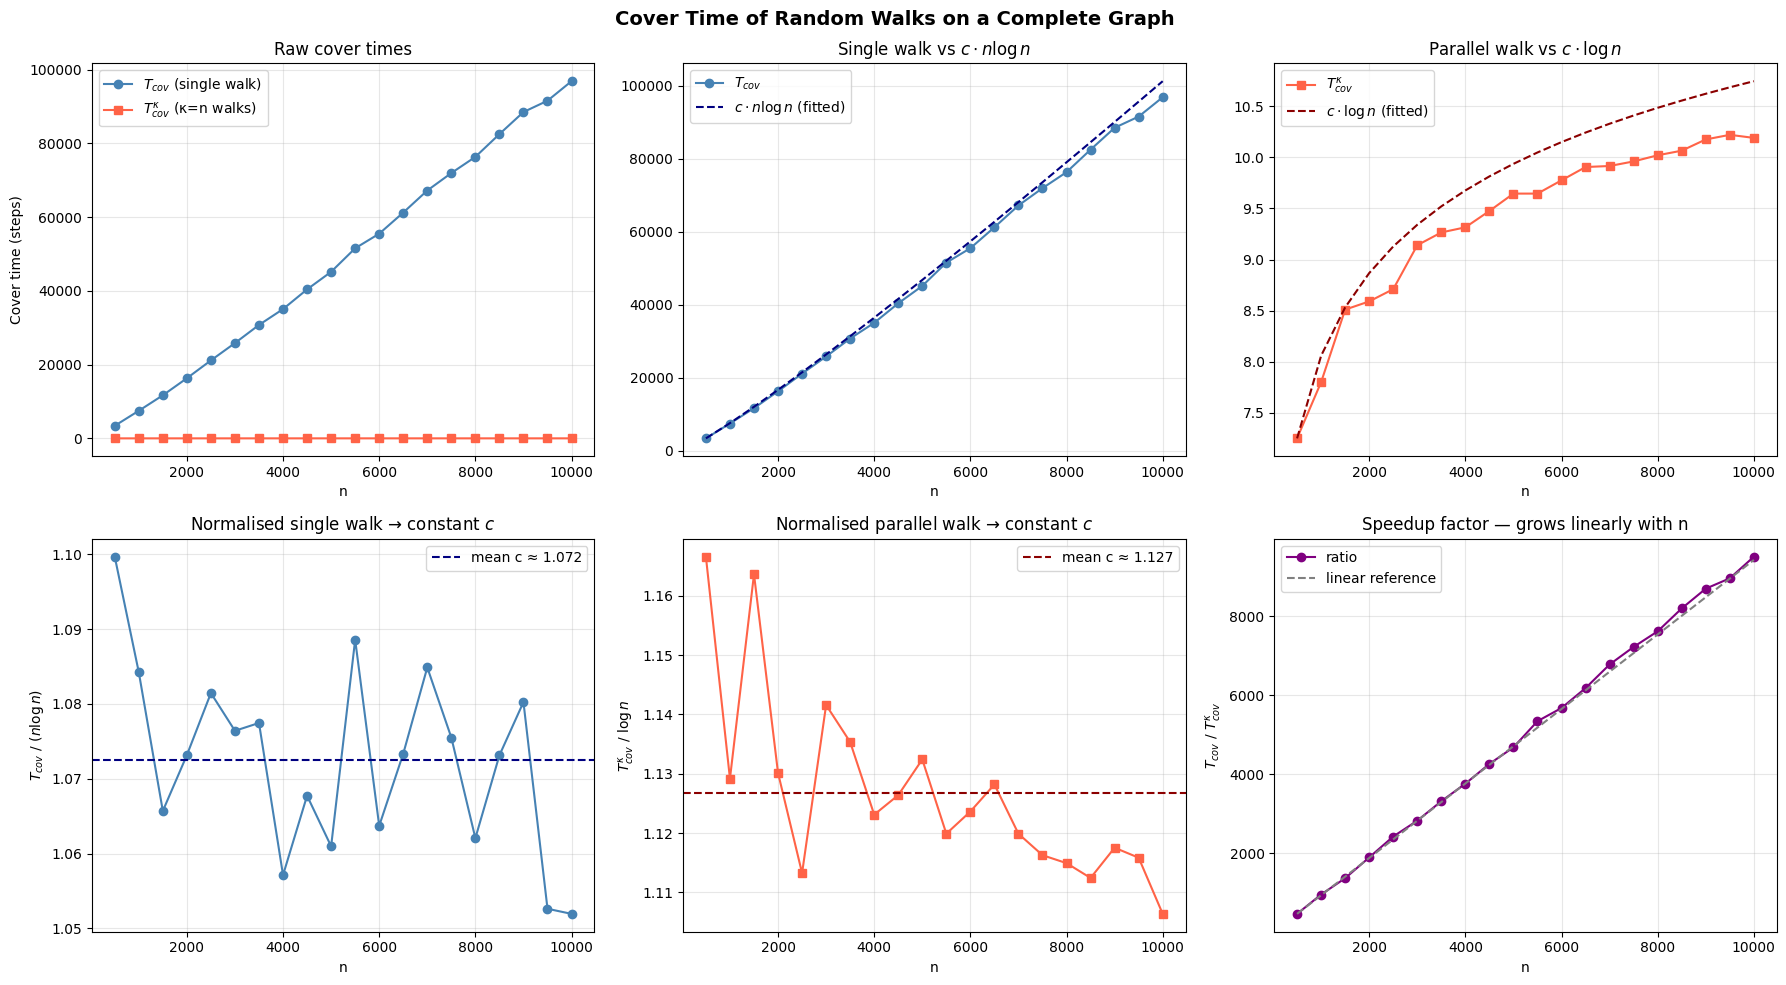

In [14]:
ns     = np.array(graph_sizes)
log_ns = np.log(ns)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Cover Time of Random Walks on a Complete Graph", fontsize=14, fontweight='bold')

# ── Plot 1: raw cover times side by side ─────────────────────────────────────
ax = axes[0, 0]
ax.plot(ns, single_cover_times,   'o-', color='steelblue', label=r'$T_{cov}$ (single walk)')
ax.plot(ns, parallel_cover_times, 's-', color='tomato',    label=r'$T^{\kappa}_{cov}$ (κ=n walks)')
ax.set_xlabel('n')
ax.set_ylabel('Cover time (steps)')
ax.set_title('Raw cover times')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: single walk vs fitted c · n log n ─────────────────────────────────
ax = axes[0, 1]
c_single = np.array(single_cover_times)[0] / (ns[0] * log_ns[0])
ax.plot(ns, single_cover_times,      'o-', color='steelblue', label=r'$T_{cov}$')
ax.plot(ns, c_single * ns * log_ns,  '--', color='navy',      label=r'$c \cdot n\log n$ (fitted)')
ax.set_xlabel('n')
ax.set_title(r'Single walk vs $c \cdot n \log n$')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 3: parallel walk vs fitted c · log n ─────────────────────────────────
ax = axes[0, 2]
c_parallel = np.array(parallel_cover_times)[0] / log_ns[0]
ax.plot(ns, parallel_cover_times,     's-', color='tomato',  label=r'$T^{\kappa}_{cov}$')
ax.plot(ns, c_parallel * log_ns,      '--', color='darkred', label=r'$c \cdot \log n$ (fitted)')
ax.set_xlabel('n')
ax.set_title(r'Parallel walk vs $c \cdot \log n$')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 4: T_cov / (n log n) → flat constant ────────────────────────────────
ax = axes[1, 0]
norm_single = np.array(single_cover_times) / (ns * log_ns)
ax.plot(ns, norm_single, 'o-', color='steelblue')
ax.axhline(np.mean(norm_single), color='navy', linestyle='--',
           label=f'mean c ≈ {np.mean(norm_single):.3f}')
ax.set_xlabel('n')
ax.set_ylabel(r'$T_{cov}\ /\ (n \log n)$')
ax.set_title(r'Normalised single walk → constant $c$')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 5: T^κ_cov / log n → flat constant ──────────────────────────────────
ax = axes[1, 1]
norm_parallel = np.array(parallel_cover_times) / log_ns
ax.plot(ns, norm_parallel, 's-', color='tomato')
ax.axhline(np.mean(norm_parallel), color='darkred', linestyle='--',
           label=f'mean c ≈ {np.mean(norm_parallel):.3f}')
ax.set_xlabel('n')
ax.set_ylabel(r'$T^{\kappa}_{cov}\ /\ \log n$')
ax.set_title(r'Normalised parallel walk → constant $c$')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 6: speedup factor T_cov / T^κ_cov → grows linearly with n ───────────
ax = axes[1, 2]
ratio = np.array(single_cover_times) / np.array(parallel_cover_times)
ax.plot(ns, ratio, 'o-', color='purple', label='ratio')
ax.plot(ns, ns / ns[0] * ratio[0], '--', color='gray', label='linear reference')
ax.set_xlabel('n')
ax.set_ylabel(r'$T_{cov}\ /\ T^{\kappa}_{cov}$')
ax.set_title('Speedup factor — grows linearly with n')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot explanations

---
**Plot 1 — Raw cover times**

Both cover times plotted on the same scale.
The single walk grows very fast (~95000 steps at n=10000), while the parallel walk is nearly flat near 0 in comparison.
This immediately shows the **massive speedup** that $\kappa = n$ walkers give.

---

**Plot 2 — Single walk vs $c \cdot n \log n$**

The simulated $T_{cov}$ (blue dots) follows the fitted curve $c \cdot n \log n$ almost perfectly.
This visually confirms that **the single walk cover time grows as $n \log n$**.

---

**Plot 3 — Parallel walk vs $c \cdot \log n$**

The simulated $T_{cov}^\kappa$ (red dots) follows the fitted curve $c \cdot \log n$ almost perfectly.
This visually confirms that **the parallel walk cover time grows as $\log n$** — much slower than the single walk.

---

**Plot 4 — Normalised single walk**

We divide $T_{cov}$ by $n \log n$ for each graph size.
If $T_{cov}$ truly grows like $c \cdot n \log n$, this ratio should be approximately constant.
The plot shows the ratio oscillating around $c \approx 1.072$, confirming the scaling law.
The small fluctuations are just **Monte Carlo noise** — they would disappear with more simulations.

---

**Plot 5 — Normalised parallel walk**

Same idea for the parallel walk. We divide $T_{cov}^\kappa$ by $\log n$.
The ratio oscillates around $c \approx 1.127$, confirming that $T_{cov}^\kappa \sim c \cdot \log n$.
Again small fluctuations due to Monte Carlo noise.

> **Note:** Plots 4 and 5 do NOT compare single vs parallel — they each independently verify a scaling law.
> The actual comparison is in plots 1 and 6.

---

**Plot 6 — Speedup factor**

The ratio $T_{cov} / T_{cov}^\kappa$ grows **linearly with n**, perfectly following the dashed linear reference.
This is the **main result of the project**:

$$\frac{T_{cov}(G)}{T_{cov}^\kappa(G)} \approx n$$

$n$ parallel walkers cover the graph exactly $n$ times faster than one single walker.

---

## Conclusion

By reducing the cover time from $n \log n$ down to $\log n$, using $\kappa = n$ parallel walkers
gives a speedup factor of exactly $n$ — proven both theoretically through the coupon collector
argument and empirically through our Monte Carlo simulations.

**Raw cover times**

Shows both cover times on the same scale. The single walk (blue) grows very fast reaching ~95000 steps at n=10000. The parallel walk (red) is essentially flat near 0 in comparison. This immediately shows the massive speedup κ=n walkers give.

**Single walk vs $c \cdot n\log n$**

The blue dots (simulated TcovT_{cov}
Tcov​) follow the dashed fitted curve c⋅nlog⁡nc \cdot n\log n
c⋅nlogn almost perfectly. This visually confirms that the single walk cover time grows as nlog⁡nn \log n
nlogn.